In [1]:
import bs4
import lxml
import pandas as pd
import urllib
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
import urllib.parse

import re
from bs4 import SoupStrainer

from urllib import request
from io import StringIO
import time
from matplotlib import pyplot as plt

import pickle as pckl



### Dons du montant >=50.000 pour les années 2009-actuel

In [24]:
url_base = "https://www.bundestag.de/parlament/praesidium/parteienfinanzierung/fundstellen50000/"
year  = "2024"

In [25]:
url_full = url_base + year
only_table = SoupStrainer('table')
table_request_text = request.urlopen(url_full).read()
table = bs4.BeautifulSoup(table_request_text, "html.parser",parse_only=only_table)
raw_table = table.find_all('table', 'table')[0]

In [26]:
df = pd.read_html(str(raw_table))[0]
df

/tmp/ipykernel_12097/1469236618.py:1: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(str(raw_table))[0]


,Partei,Spende,Spender,Eingang der Spende oder der Spendenan-­ kündigung,"Eingang der Anzeige, Drucksache"
,Juli 2024,Juli 2024,Juli 2024,Juli 2024,Juli 2024
,April 2024,April 2024,April 2024,April 2024,April 2024
0,Dezember 2024,Dezember 2024,Dezember 2024,Dezember 2024,Dezember 2024
1,SPD,35.001 Euro,Verband der Bayerischen Metall und Elektro-Ind...,30.12.2024,30.12.2024 Drs. 20/14692
2,FDP,50.000 Euro,Verband der Bayerischen Metall- und Elektro-In...,30.12.2024,30.12.2024 Drs. 20/14692
3,FDP,100.000 Euro,Jörg Bantleon Arcisstr. 50 80799 München,27.12.2024,30.12.2024 Drs. 20/14692
4,FDP,200.000 Euro,Futrue GmbH Am Haag 14 82166 Gräfelfing,27.12.2024,30.12.2024 Drs. 20/14692
...,...,...,...,...,...
141,Bündnis 90/ Die Grünen,50.001 Euro,Verband der Bayerischen Metall- und Elektro-In...,27.12.2023,30.01.2024 Drs. 20/10781
142,FDP,51.000 Euro,Ulrich Horst Marseille Sportallee 1 22335 Hamburg,15.1.2024,16.01.2024 Drs. 20/10781


In [27]:
dfs = []
# get table
year = 2024
for year in range(2009,2026):
    url_full = url_base + str(year)
    only_table = SoupStrainer('table')
    table_request_text = request.urlopen(url_full).read()
    table = bs4.BeautifulSoup(table_request_text, "html.parser",parse_only=only_table)
    raw_table = table.find_all('table', 'table')[0]
    df = pd.read_html(StringIO(str(raw_table)))[0]

    # clean up
    df_dons = df.iloc[:,: 5].set_axis(['Partie', 'Montant', 'Donneur', 'Date', 'Date Publication'], axis=1)
    df_dons = df_dons[df_dons['Montant'].str.match('\d+\.\d\d\d')]
    df_dons = df_dons[df_dons['Date'].str.match('\d{1,2}.\d\d.\d\d\d\d$', flags=re.U)]
    df_dons['Montant'] = df_dons['Montant'].apply(lambda x: re.search(r'\d{1,3}(\.\d{3})*', x).group(0))
    df_dons['Montant'] = df_dons['Montant'].apply(lambda x: int(x.replace('.','')))
    df_dons['Date'] = pd.to_datetime(df_dons['Date'],format= '%d.%m.%Y')
    df_dons
    dfs.append(df_dons)

df_don_complet = pd.concat(dfs)
df_don_complet

KeyboardInterrupt: 

## Financement des parties

In [ ]:
import tabula

In [ ]:
parties = [
    'CDU',
    'SPD',
    'GRÜNE',
    'AfD',
    'FDP',
    'CSU',
    'DIE LINKE'
]

In [ ]:
from PyPDF2 import PdfReader

rapport_path = "rechenschaftsberichte/2022.pdf"
reader = PdfReader(rapport_path)
number_of_pages = len(reader.pages)


# récuperer la page correspondante à chaque partie
page = reader.pages[0]
text = page.extract_text()
parties_trouves = []
pages_correspondants = []
for partie in parties:
    page_trouve = re.findall(f'(?<={partie})\s+\d+', text)
    if len(page_trouve) > 0:
        print(page_trouve)
        page_trouve = int(page_trouve[0])
        print(partie, " ", page_trouve)
        parties_trouves.append(partie)
        pages_correspondants.append(page_trouve)
print(parties_trouves)
print(pages_correspondants)

# récuperer le rapport financier de chaque partie
dfs_rapports = tabula.read_pdf(rapport_path,pages=pages_correspondants)
print(len(dfs_rapports))

for dfs in dfs_rapports:
    print(dfs)

len(dfs_rapports)
dfs_rapports

[' 3']
CDU   3
[' 85']
SPD   85
['  163']
GRÜNE   163
[' 237']
AfD   237
[' 279']
FDP   279
['  309']
CSU   309
['  333']
DIE LINKE   333
['CDU', 'SPD', 'GRÜNE', 'AfD', 'FDP', 'CSU', 'DIE LINKE']
[3, 85, 163, 237, 279, 309, 333]
7
                              Einnahmen- und      Unnamed: 0  2022 Unnamed: 1  \
0                                        NaN             EUR   NaN          %   
1                 Einnahmen der Gesamtpartei             NaN   NaN        NaN   
2                       1. Mitgliedsbeiträge   36.405.599,34   NaN      26,70   
3      2. Mandatsträgerbeiträge und ähnliche             NaN   NaN        NaN   
4                       regelmäßige Beiträge   22.323.445,17   NaN      16,37   
5        3. Spenden von natürlichen Personen   14.008.708,90   NaN      10,27   
6       4. Spenden von juristischen Personen    7.339.887,57   NaN       5,38   
7     5. Einnahmen aus Unternehmenstätigkeit             NaN  0,00       0,00   
8            5a. Einnahmen aus Beteiligu

[                              Einnahmen- und      Unnamed: 0  2022 Unnamed: 1  \
 0                                        NaN             EUR   NaN          %   
 1                 Einnahmen der Gesamtpartei             NaN   NaN        NaN   
 2                       1. Mitgliedsbeiträge   36.405.599,34   NaN      26,70   
 3      2. Mandatsträgerbeiträge und ähnliche             NaN   NaN        NaN   
 4                       regelmäßige Beiträge   22.323.445,17   NaN      16,37   
 5        3. Spenden von natürlichen Personen   14.008.708,90   NaN      10,27   
 6       4. Spenden von juristischen Personen    7.339.887,57   NaN       5,38   
 7     5. Einnahmen aus Unternehmenstätigkeit             NaN  0,00       0,00   
 8            5a. Einnahmen aus Beteiligungen             NaN  0,00       0,00   
 9        6. Einnahmen aus sonstigem Vermögen    1.952.077,46   NaN       1,43   
 10         7. Einnahmen aus Veranstaltungen,             NaN   NaN        NaN   
 11           Ve

In [ ]:
partie = 'CDU'
annee = '2024'
data = {'partie': [], 'depense': [], 'amont': [], 'annee': []}


for i in range(len(dfs_rapports)):
    df_rapport_financement = pd.DataFrame(columns=['Partie','Depense','Amont','Annee'])
    dfs_test = dfs_rapports[i].copy().iloc[:, 0:2].dropna()
    #print(dfs_test)
    regex = r'-?\d{1,3}(\.\d{3})*'
    dfs_test = dfs_test.set_axis(['Depense','Amont'],axis=1)
    dfs_test = dfs_test[dfs_test['Amont'].str.match(regex)]
    dfs_test['Amont'] = dfs_test['Amont'].apply(lambda x: x.replace(' ',''))

    dfs_test['Amont']= dfs_test['Amont'].apply(lambda x: x[:-3])
    dfs_test['Amont']= dfs_test['Amont'].apply(lambda x: re.search(regex, x).group(0))
    dfs_test['Amont'] = dfs_test['Amont'].apply(lambda x: int(x.replace('.','')))

    # Trouver les dons
    #print(dfs)
   # print(dfs_test)
    print(dfs_test[dfs_test['Depense'].str.contains('Spenden')])

    

                                Depense     Amont
5   3. Spenden von natürlichen Personen  14008708
6  4. Spenden von juristischen Personen   7339887
                                Depense    Amont
5   3. Spenden von natürlichen Personen  7429801
6  4. Spenden von juristischen Personen  1805152
                                Depense    Amont
5   3. Spenden von natürlichen Personen  4837530
6  4. Spenden von juristischen Personen   697190
                                Depense    Amont
5   3. Spenden von natürlichen Personen  3866320
6  4. Spenden von juristischen Personen   104240
                                 Depense    Amont
4   3. Spenden l()n natürlichen Personen  3793539
5  4. Spenden l()n juristischen Personen  1678265
                                Depense    Amont
5   3. Spenden von natürlichen Personen  3171066
6  4. Spenden von juristischen Personen  1517641
                                Depense    Amont
5   3. Spenden von natürlichen Personen  2108832
6  4. Spenden 

# Résultats des élection fédérales allemandes

In [ ]:
url = 'https://www.bundestag.de/parlament/wahlen/ergebnisse_seit1949-244692'
only_table = SoupStrainer('table')
table_request_text = request.urlopen(url).read()
table = bs4.BeautifulSoup(table_request_text, "html.parser",parse_only=only_table)
raw_table = table.find_all('table', 'table')[0]
df = pd.read_html(str(raw_table))[0]

/tmp/ipykernel_8252/2794489338.py:6: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(str(raw_table))[0]


In [ ]:
df_formatted = df.copy()
df_formatted.iloc[:,1:] = df_formatted.iloc[:,1:].apply(lambda x:x/10)

/tmp/ipykernel_8252/4025240561.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0     24.1
1     32.9
2     41.5
3     33.8
4     35.2
5     38.5
6     35.2
7     41.5
8     43.8
9     44.3
10    48.8
11    44.5
12    48.6
13    44.9
14    46.1
15    47.6
16    45.3
17    50.2
18    45.2
19    31.0
Name: CDU/CSU, dtype: float64' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_formatted.iloc[:,1:] = df_formatted.iloc[:,1:].apply(lambda x:x/10)
/tmp/ipykernel_8252/4025240561.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0     25.7
1     20.5
2     25.7
3     23.0
4     34.2
5     38.5
6     40.9
7     36.4
8     33.5
9     37.0
10    38.2
11    42.9
12    42.6
13    45.8
14    42.7
15    39.3
16    36.2
17    31.8
18    28.8
19    29.2
Name: SPD, dtype: float64' has dtype incompatible with int6

In [ ]:
df_formatted

,Jahr,CDU/CSU,SPD,FDP,Die Grünen,Bündnis 90/Die Grünen,Die Linke. PDS,AfD,Sonstige
0,2021,24.1,25.7,11.5,NaN,14.8,4.9,10.3,8.7
1,2017,32.9,20.5,10.7,NaN,8.9,9.2,12.6,5.0
2,2013,41.5,25.7,4.8,NaN,8.4,8.6,4.7,6.3
3,2009,33.8,23.0,14.6,NaN,10.7,11.9,NaN,6.0
4,2005,35.2,34.2,9.8,NaN,8.1,8.7,NaN,4.0
5,2002,38.5,38.5,7.4,NaN,8.6,4.0,NaN,3.0
6,1998,35.2,40.9,6.2,NaN,6.7,5.1,NaN,5.9
7,1994,41.5,36.4,6.9,NaN,7.3,4.4,NaN,3.5
8,1990,43.8,33.5,11.0,3.8,1.2,2.4,NaN,4.3
9,1987,44.3,37.0,9.1,8.3,NaN,NaN,NaN,1.3


# Scraping sujets articles

In [2]:
only_filter_count = SoupStrainer(class_="filter-count")
def get_faz_mentions(subject, start_year=1993,end_year = 2024,sleep=0):
    subject = subject.replace(" ","+")
    mentions = []
    years = []
    for year in range(start_year,end_year+1):
        url = f"https://fazarchiv.faz.net/faz-portal/faz-archiv?q={subject}&source=&max=10&sort=&offset=0&&_ts={int(time.time())}&DT_from=01.01.{year}&DT_to=01.01.{year+1}&timeFilterType=0#hitlist"
        table_request_text = request.urlopen(url).read()
        site = bs4.BeautifulSoup(table_request_text, "html.parser",parse_only=only_filter_count)
        site = str(site)
        site = site.replace('.','')
        filter_results = re.findall(pattern=r'(?<=\()\d+(?=\))',string=str(site))
        if len(filter_results) > 0:
            number_of_mentions = max([int(x) for x in filter_results])
        else:
            number_of_mentions = 0
        mentions.append(number_of_mentions)
        years.append(year)
        time.sleep(sleep)
    return pd.DataFrame({'Year':years, 'Mentions': mentions}).set_index('Year')

In [4]:
def get_lemonde_mentions(subject, start_year=2010,end_year = 2024,sleep=0):
    subject = subject.replace(" ","+")
    only_page_count_le_monde = SoupStrainer(class_="river__pagination river__pagination--page-search ")
    only_article_section_le_monde = SoupStrainer(class_="teaser teaser--inline-picture  ")

    mentions = []
    years = []

    options = webdriver.ChromeOptions()
    options.add_argument("--headless=new") # for Chrome >= 109

    driver = webdriver.Chrome(options=options)

    # Provoquer demande d'acceptation de cookies
    test_url = f"https://lemonde.fr/recherche/?search_keywords={'test'}&start_at=1%2F1%2F{2000}&end_at=1%2F1%2F{2001}&search_sort=relevance_desc"
    driver.get(test_url)
    driver.add_cookie({"name": "euconsent-v2", "value": "CQMgjEAQMgjEAFzABBFRBbFsAP_gAAAAAAqII7MB7C7OQSFicX51AOsESY1ewkBSoEAgBAABgQgBABgQsIwRkGAKIADAAqAKAAIAImRBIQAtGAjABAAAQIAAASCEAECAABAAJKAAAEAQAAEACAgACQEAAAAAgEAAAAQAgAIAAEooQERAAgAgLAAAIAABAIAEAgAIAAAAAAAAAAAAAGAAAAAAAAAAAAAAAAAAEEBAARBQiIACwICQggDCCBACoIQAIAAAQAAAAwAAAAAwIUAYACDABAAAAAAAEAAAAARAAgAAAgAQgAAAAIEAAAAAAAAAAAAgAABAAAAAAAAAAAAQAAIAAAAAAAAAAAAIAQAAAAAAAICAAAAAQFgAAAAAAgEAAAAAAAAAAAAAAAAAAACAMEgAwABBAQdABgACCAhCADAAEEBCUAGAAIICFIAMAAQQELQAYAAggIA", "sameSite": "Lax"})
    driver.add_cookie({"name": "lmd_consent", "value": "%7B%22userId%22%3A%22e5912aad-e232-4533-9da0-cdd43a427087%22%2C%22timestamp%22%3A%221739010630.749987654%22%2C%22version%22%3A1%2C%22cmpId%22%3A371%2C%22displayMode%22%3A%22cookiewall%22%2C%22purposes%22%3A%7B%22analytics%22%3Atrue%2C%22ads%22%3Atrue%2C%22personalization%22%3Atrue%2C%22mediaPlatforms%22%3Atrue%2C%22social%22%3Atrue%7D%7D", "sameSite": "Lax"})
    time.sleep(3)

    # commencer scrapping
    for year in range(start_year,end_year+1):
        url = f"https://lemonde.fr/recherche/?search_keywords={subject}&start_at=1%2F1%2F{year}&end_at=1%2F1%2F{year+1}&search_sort=relevance_desc"

        try:
            driver.get(url)
        except:
            print('timeout')
            driver.execute_script("window.stop()")        
        
        time.sleep(sleep)
        
        # Get the page source after JavaScript has rendered the content
        page_source = driver.page_source
        site = bs4.BeautifulSoup(page_source, 'html.parser',parse_only=only_page_count_le_monde)
        site = str(site)
        filter_results = re.findall(pattern=r'(?<=page\=)\d+(?=\")',string=str(site))
        if len(filter_results) > 0:
            number_of_pages = max([int(x) for x in filter_results])
        else:
            number_of_pages = 1


        # number of sections
        article_sections = bs4.BeautifulSoup(page_source, 'html.parser',parse_only=only_article_section_le_monde)
        number_of_articles = len(re.findall(r'\<section class\=',str(article_sections)))
        mentions.append(number_of_pages * number_of_articles)
        years.append(year)
    driver.close()
    return pd.DataFrame({'Year':years, 'Mentions': mentions}).set_index('Year')



In [4]:
""" url = 'https://www.liberation.fr/recherche/?query=refugies'
# Libération
options = webdriver.ChromeOptions()
driver = webdriver.Chrome(options=options)
driver.get(url)
time.sleep(10)
cookies = driver.get_cookies()
with open('scrapping/liberation_cookies.pckl','wb') as f:
    pckl.dump(cookies,f) """

" url = 'https://www.liberation.fr/recherche/?query=refugies'\n# Libération\noptions = webdriver.ChromeOptions()\ndriver = webdriver.Chrome(options=options)\ndriver.get(url)\ntime.sleep(10)\ncookies = driver.get_cookies()\nwith open('scrapping/liberation_cookies.pckl','wb') as f:\n    pckl.dump(cookies,f) "

In [5]:
def get_liberation_mentions(subject, start_year=2010,end_year = 2024,sleep=3):
    subject = subject.replace(" ","+")

    url = f'https://www.liberation.fr/recherche/?query={subject}'

    mentions = []
    years = []

    # Libération
    options = webdriver.ChromeOptions()
    #options.add_argument("--headless=new") # for Chrome >= 109
    driver = webdriver.Chrome(options=options)
    driver.get(url)
    time.sleep(3)
    driver.switch_to.frame(driver.find_element(By.ID,"sp_message_iframe_1223720"))
    cookie_notice = driver.find_element(By.ID, 'notice')
    cookie_notice.find_element(By.XPATH,'//*[@title="Accepter et continuer"]').click()

    #print(driver.find_element(By.CLASS_NAME, 'message-component message-button no-children focusable start-focus sp_choice_type_11'))
    driver.switch_to.default_content()
    tries = 0
    time.sleep(sleep)
    for year in range(start_year,end_year+1):
        #print(driver.find_elements(By.ID, "datepicker_from"))
        while (driver.find_elements(By.ID, "datepicker_from") == []):
            if tries >= 3:  
                raise Exception(ConnectionError)
            driver.refresh()
            time.sleep(sleep)
            tries += 1
        datepicker_from = driver.find_element(By.ID,"datepicker_from")
        datepicker_from.clear()

        datepicker_from.send_keys(f"01/01/{year}")
        datepicker_from.send_keys(Keys.TAB)
        driver.find_element(By.ID,"datepicker_to").send_keys(f"01/01/{year+1}")
        driver.execute_script('searchPage.applyDateRange();')
        time.sleep(1)

        only_filter_liberation = SoupStrainer(id="resultdata")
        page_source = driver.page_source
        site = bs4.BeautifulSoup(page_source, 'html.parser',parse_only=only_filter_liberation)
        pattern = r'(?<=Affichage de )\d+(?= résultats)'

        filter_results = re.findall(pattern,str(site))
        if len(filter_results) > 0:
            number_of_mentions = filter_results[0]
        else:
            number_of_mentions = 0
        years.append(year)
        mentions.append(int(number_of_mentions))
    driver.close()
    df = pd.DataFrame({'Year':years, 'Mentions': mentions}).set_index('Year')
    return df


In [6]:
only_search_result_taz = SoupStrainer(class_='typo-teaser-text-bold  mgb-medium')

def do_taz_search(subject, year_from, month_from, month_to):
    if month_from == month_to:
        year_to = year_from + 1
    else:
        year_to = year_from
    url = f'https://taz.de/!s={subject}&eTagAb={year_from}-{month_from}-01&eTagBis={year_to}-{month_to}-01/'
    table_request_text = request.urlopen(url).read()
    site = bs4.BeautifulSoup(table_request_text, "html.parser",parse_only=only_search_result_taz)
    site = str(site)

    pattern = r'(?<=von )\d+(?= \<\/p\>)'
    filter_results = re.findall(pattern, site)
    if len(filter_results) > 0:
        number_of_mentions = filter_results[0]
    else:
        number_of_mentions = 0
    
    return int(number_of_mentions)

def get_taz_mentions(subject, start_year=2010,end_year = 2024,sleep=3):
    subject = subject.replace(" ","+")

    mentions = []
    years = []

   
    for year in range(start_year,end_year+1):
        month = 1
        following_month = month # only relevant for monthly search
        number_of_mentions = do_taz_search(subject, year, month, following_month)
        if(number_of_mentions >= 1000):
            # max limit reached, do monthly search
            print(f'Starting {year} monthly serach')
            number_of_mentions = 0
            for month in range(1,12):
                number_of_mentions += do_taz_search(subject, year, month, month +1)


        years.append(year)
        mentions.append(int(number_of_mentions))
        time.sleep(sleep)

    return pd.DataFrame({'Year':years, 'Mentions': mentions}).set_index('Year')

In [8]:
def get_mentions(subjects, start_year=2010,end_year = 2024,sleep=3):
    subjects_original = subjects.copy()
    subjects = [urllib.parse.quote_plus(subject) for subject in subjects]
    print (subjects)
    print('Getting FAZ')
    try:
        mentions_faz_df = get_faz_mentions(subjects[0], start_year, end_year, sleep)
    except:
        mentions_faz_df = get_faz_mentions(subjects[0], start_year, end_year, sleep)

    print('Getting TAZ')
    try:
        mentions_taz_df = get_taz_mentions(subjects[0], start_year, end_year, sleep)
    except:
        mentions_taz_df = get_taz_mentions(subjects[0], start_year, end_year, sleep)

    print('Getting LeMonde')
    try:
        mentions_lemonde_df = get_lemonde_mentions(subjects[1],start_year, end_year,sleep)
    except:
        mentions_lemonde_df = get_lemonde_mentions(subjects[1],start_year, end_year,sleep)
        
    print('Getting Liberation')
    try:
        mentions_liberation_df = get_liberation_mentions(subjects[1],start_year, end_year,sleep)
    except:
        mentions_liberation_df = get_liberation_mentions(subjects[1],start_year, end_year,sleep)
        

    print('Done')

    mentions = mentions_faz_df.copy()
    mentions['taz'] = mentions_taz_df['Mentions']

    mentions['liberation'] = mentions_liberation_df['Mentions']
    mentions['lemonde'] = mentions_lemonde_df['Mentions']
    mentions = mentions.rename(columns={'Mentions':'faz'})
    with open(f'scrapping/{subjects_original[0]}_{subjects_original[1]}_{start_year}_{end_year}.pckl', 'wb') as f:
        mentions.to_pickle(f)
    
    print(mentions)

    return mentions


In [9]:
def get_mentions_only_de_array(subjects_dict,id, start_year=2010,end_year = 2024,sleep=3):
    first = True
    years = sorted(subjects_dict)
    # find the first term
    if start_year in years:
        first_term = subjects_dict[start_year]
    elif 0 in years:
        first_term = subjects_dict[0]
    else: 
        for year in range(1900,start_year):
            if year in years:
                first_term = subjects_dict[year]

    years = [year for year in years if year != 0 and year >= start_year and year <= end_year ]
    if len(years) == 0:
        intervals = [(start_year,end_year)]
    else:
        intervals = [(start_year,years[0]-1)]+[(year, years[i+1]-1) for i,year in enumerate(years[:-1])]+[(years[-1],end_year)]
    intervals = [interval for interval in intervals if interval[0] <= interval[1]]
    dfs = []
    print(intervals)
    for interval in intervals:
        if first:
            subjects = first_term
        else:
            subjects = subjects_dict[interval[0]]
        
        first = True
        for subject in subjects:
            subject = urllib.parse.quote_plus(subject) 
            print(subject)
            print(interval)
            print('Getting FAZ')

            if  first: 
                try:
                    mentions_faz_df = get_faz_mentions(subject, interval[0], interval[1], sleep)
                except:
                    mentions_faz_df = get_faz_mentions(subject, interval[0], interval[1], sleep)

                print('Getting TAZ')
                try:
                    mentions_taz_df = get_taz_mentions(subject, interval[0], interval[1], sleep)
                except:
                    mentions_taz_df = get_taz_mentions(subject, interval[0], interval[1], sleep)
                first = False
            else:
                try:
                    mentions_faz_df += get_faz_mentions(subject, interval[0], interval[1], sleep)
                except:
                    mentions_faz_df += get_faz_mentions(subject, interval[0], interval[1], sleep)

                print('Getting TAZ')
                try:
                    mentions_taz_df += get_taz_mentions(subject, interval[0], interval[1], sleep)
                except:
                    mentions_taz_df += get_taz_mentions(subject, interval[0], interval[1], sleep)

        print("Mentions FAZ", mentions_faz_df)
        print("Mentions TAZ", mentions_taz_df)
        mentions = mentions_faz_df.copy()
        mentions['taz'] = mentions_taz_df['Mentions']
        mentions = mentions.rename(columns={'Mentions':'faz'})
        dfs.append(mentions)
            
    print('Done')

    final_df = pd.concat(dfs)
    with open(f'scrapping/de/{id}_{start_year}_{end_year}.pckl', 'wb') as f:
         final_df.to_pickle(f)

    

    return final_df


In [ ]:
mentions_df = get_mentions(['gaza','gaza'])
mentions_df

Getting FAZ
Getting TAZ
Starting 2024 monthly serach
Getting LeMonde
Getting Liberation
Done


,faz,taz,liberation,lemonde
Year,,,,
2010,488,235,302,680
2011,432,167,274,680
2012,407,184,235,520
2013,223,84,129,440
2014,889,428,580,840
2015,289,125,207,400
2016,141,72,121,240
2017,197,106,141,280
2018,282,115,292,360


(0.0, 0.21575342465753422)

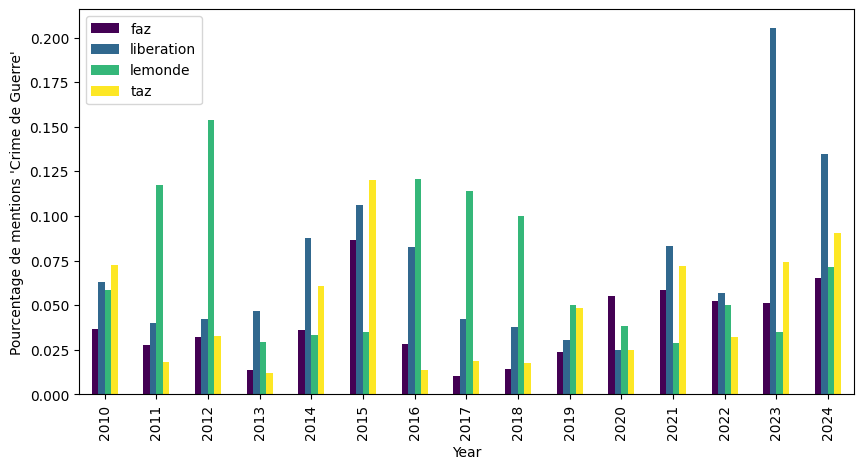

In [ ]:
df_all = mentions_df /mentions_df_all
df_all.plot(kind='bar',colormap='viridis',figsize=(10,5))
plt.ylabel('Pourcentage de mentions \'Crime de Guerre\'')
plt.ylim(0)

In [8]:
mots_fr=['réforme','identité','justice sociale','libéralisme','nationalisme',
"droits de l'homme",'economie','santé publique','technologie','education','corruption','fédéralisme','diversité','religion','islam','catholique','juif','gouvernance',
'economie','société','environnement','administration','politique','législation','régulation','transparence','croissance', 'chômage', 'inflation', 'fiscalité', 'dette publique', 
'marché', 'capitalisme', 'socialisme','inégalités', 'pauvreté', 'solidarité', 'cohésion sociale', 'exclusion', 'intégration','société','changement climatique', 'développement durable', 
'biodiversité', 'énergie renouvelable', 'pollution','terrorisme', 'défense', 'armée', 'police', 'cyber sécurité', 'conflit','droits','liberté',"liberté d'expression", 'droits civiques', 
'discrimination', 'égalité des sexes', 'LGBTQ','santé', 'assurance maladie', 'épidémie', 'vaccination', 'prévention','innovation', 'intelligence artificielle', 'numérique', 'données personnelles', 
'surveillance','culture', 'patrimoine', 'identité culturelle', 'diversité culturelle', 'arts', 'médias','diplomatie', 'géopolitique', 'union européenne', 'globalisation', 'souveraineté', 'nation','justice',
'système judiciaire', 'victimes', 'peine de mort', 'réinsertion', 'corruption','punition','asile', 'réfugiés', 'frontières', 'intégration', 'xénophobie','laïcité', 'culte', 'extrémisme','décentralisation', 'régionalisation', 
'autonomie', 'centralisation']


mots_de = ['Reform', 'Identität', 'soziale Gerechtigkeit', 'Liberalismus', 'Nationalismus',
'Menschenrechte', 'Wirtschaft', 'öffentliche Gesundheit', 'Technologie', 'Bildung', 'Korruption', 'Föderalismus', 'Vielfalt', 'Religion', 'Islam', 'katholisch', 'jüdisch', 'Governance',
'Wirtschaft', 'Gesellschaft', 'Umwelt', 'Verwaltung', 'Politik', 'Gesetzgebung', 'Regulierung', 'Transparenz', 'Wachstum', 'Arbeitslosigkeit', 'Inflation', 'Besteuerung', 'Verschuldung',
'Markt', 'Kapitalismus', 'Sozialismus', 'Ungleichheit', 'Armut', 'Solidarität', 'sozialer Zusammenhalt', 'Ausschluss', 'Integration', 'Gesellschaft', 'Klimawandel', 'nachhaltige Entwicklung',
'Biodiversität', 'erneuerbare Energie', 'Umweltverschmutzung', 'Terrorismus', 'Verteidigung', 'Armee', 'Polizei', 'Cybersicherheit', 'Konflikt', 'Rechte', 'Freiheit', 'Meinungsfreiheit', 'Bürgerrechte',
'Diskriminierung', 'Gleichstellung der Geschlechter', 'LGBTQ', 'Gesundheit', 'Krankenversicherung', 'Epidemie', 'Impfung', 'Prävention', 'Innovation', 'künstliche Intelligenz', 'digital', 'persönliche Daten',
'Überwachung', 'Kultur', 'Kulturerbe', 'kulturelle Identität', 'kulturelle Vielfalt', 'Künste', 'Medien', 'Diplomatie', 'Geopolitik', 'Europäische Union', 'Globalisierung', 'Souveränität', 'Nation', 'Gerechtigkeit',
'Justizsystem', 'Opfer', 'Todesstrafe', 'Wiedereingliederung', 'Korruption', 'Bestrafung', 'Asyl', 'Flüchtlinge', 'Grenzen', 'Integration', 'Fremdenfeindlichkeit', 'Laizismus', 'Kult', 'Extremismus', 'Dezentralisierung', 'Regionalisierung',
'Autonomie', 'Zentralisierung']



In [ ]:
[mot for mot in zip(mots_de,mots_fr)]

[('démocratie', 'Demokratie'),
 ('populisme', 'Populismus'),
 ('écologie', 'Ökologie'),
 ('immigration', 'Immigration'),
 ('souveraineté', 'Souveränität'),
 ('égalité', 'Gleichheit'),
 ('sécurité', 'Sicherheit'),
 ('réforme', 'Reform'),
 ('identité', 'Identität'),
 ('justice sociale', 'soziale Gerechtigkeit'),
 ('libéralisme', 'Liberalismus'),
 ('nationalisme', 'Nationalismus'),
 ("droits de l'homme", 'Menschenrechte'),
 ('economie', 'Wirtschaft'),
 ('santé publique', 'öffentliche Gesundheit'),
 ('technologie', 'Technologie'),
 ('education', 'Bildung'),
 ('corruption', 'Korruption'),
 ('fédéralisme', 'Föderalismus'),
 ('diversité', 'Vielfalt'),
 ('religion', 'Religion'),
 ('islam', 'Islam'),
 ('catholique', 'katholisch'),
 ('juif', 'jüdisch'),
 ('gouvernance', 'Governance'),
 ('economie', 'Wirtschaft'),
 ('société', 'Gesellschaft'),
 ('environnement', 'Umwelt'),
 ('administration', 'Verwaltung'),
 ('politique', 'Politik'),
 ('législation', 'Gesetzgebung'),
 ('régulation', 'Regulierung'

In [12]:
data = {
    1: {
        0: ["Renten", "Alterssicherung"],
    },
    5: {
        1986: ["Inflation"],
        1989: ["Wirtschaft", "Steuern", "Inflation"],
        1990: ["Steuern", "Steuererhöhung", "Gebühren", "Abgaben"],
        1993: ["Steuern", "Steuererhöhung", "Autobahngebühr"],
        1994: ["Steuern", "Steuererhöhung"],
        2006: ["Lebenshaltungskosten",  "Benzinpreise", "Teuro", "Inflation"],
        2013: ["Lebenshaltungskosten",  "Benzinpreise", "Teuro", "Inflation"],
        2015: ["Lebenshaltungskosten",  "Benzinpreise", "Inflation"],
    },
    10: {
        1986: ["Steuern", "Steuerreform"],
        1989: ["Wirtschaft", "Steuern", "Inflation"],
        1990: ["Steuern", "Steuererhöhung", "Gebühren", "Abgaben"],
        1993: ["Steuern", "Steuererhöhung", "Autobahngebühren"],
        1994: ["Steuern", "Steuererhöhungen"],
        2006: ["Steuern", "Steuererhöhungen"],
        2014: ["Steuern", "Steuererhöhungen", "Steuerhinterziehung"],
        2015: ["Steuern", "Steuererhöhungen", "Steuerhinterziehung"],
    },
    13: {
        1990: ["Wirtschaftspolitik"],
        1993: ["Wirtschaftspolitik", "Wirtschaftslage"],
        1994: ["Wirtschaftswachstum", "Wirtschaftslage"],
        2008: ["Rezession"],
        2011: ["Wirtschaftslage", "Rezession"],
        2012: ["Wirtschaftslage"],
        2020: ["Wirtschaftslage", "Konjunkturpaket", "Corona-Hilfen"],
    },
    14: {
        0: ["Arbeitslosigkeit", "Arbeitsplätze", "Ausbildungsplätze"],  # Entrée uniquement pour l'année de base
    },
    15: {
        1989: ["Umweltschutz"],
        1994: ["Umweltschutz", "Ozon"],
        1995: ["Umweltschutz", "Ölplattform Brent Spar"],
        2005: ["Umweltschutz", "Atomtransport"],
        2006: ["Umweltschutz", "Hochwasser", "Flut"],
        2007: ["Umweltschutz", "Klima", "Klimawandel"],
        2008: ["Erneuerbare Energien"],
        2012: ["Umweltschutz", "Klima", "Klimawandel", "Erneuerbare Energien", "Energiewende"],
        2013: ["Umweltschutz", "Klimawandel"],
        2016: ["Umweltschutz", "Klimawandel", "Klimagipfel"],
        2019: ["Umweltschutz", "Klimawandel", "Schutz von Insekten"],
        2020: ["Umweltschutz", "Klimawandel", "Artenschutz"],
    },
    19: {
        0: ["Kindergartenplätze"],  # Entrée uniquement pour l'année de base
        1996: ["Familie", "Kinder", "Jugend"],
    },
    20: {
        1989: ["Gesundheitsreform"],
        1990: ["Gesundheitswesen", "Pflegenotstand"],
        1994: ["Gesundheitswesen"],
        2006: ["Gesundheitswesen", "Pflegeversicherung"],
        2011: ["Gesundheitswesen", "Gesundheitsreform", "Pflegeversicherung"],
        2012: ["Gesundheitswesen", "Gesundheitspolitik", "Pflegeversicherung"],
        2014: ["Gesundheitswesen", "Gesundheitspolitik", "Pflegeversicherung"],
        2022: ["Gesundheitswesen", "Gesundheitspolitik", "Pflegeversicherung"],
    },
    23: {
        1986: ["Innere Sicherheit", "Kriminalität", "Terrorismus", "härtere Strafen", "Kronzeugenregelung"],
        1989: ["Innere Sicherheit", "Ruhe und Ordnung"],
        1990: ["Ruhe und Ordnung", "Kriminalität"],
        2008: ["Jugendkriminalität"],
        2011: ["Kriminalität", "Jugendkriminalität", "Ruhe und Ordnung"],
        2016: ["Kriminalität", "Ruhe und Ordnung", "mehr Polizei"],
        2019: ["Kriminalität", "Ruhe und Ordnung", "mehr Polizei", "Innere Sicherheit"],
        2020: ["Kriminalität", "Ruhe und Ordnung", "mehr Polizei", "Innere Sicherheit"],
        2021: ["Kriminalität", "Ruhe und Ordnung", "mehr Polizei", "Innere Sicherheit"],
    },
    27: {
        1986: ["Politische Moral", "Spendenaffären", "Flick"],
        1993: ["Partei Affäre", "Politikverdruß"],
        2001: ["Partei Affäre", "Politikverdruß", "Politik allgemein"],
        2002: ["Partei Affäre", "Politikverdruß"],
        2005: ["Partei Affäre", "Politikverdruß","Spenden affäre"],
        2006: ["Partei Affäre", "Politikverdruß"],
    },
    30: {
        1989: ["Bildungspolitik", "Schulpolitik"],
        1997: ["Studentenproteste", "Bildung"],
        1999: ["Schule", "Bildung"],
        2002: ["Schule", "Bildung", "Pisa"],
    },
    53: {
        1986: ["Ausländer", "Asylanten", "Aussiedler"],
        1989: ["Asylanten", "Asyl"],
        2005: ["Asylanten", "Asyl"],
        2018: ["Ausländerfeindlichkeit"],
    },
    54: {
        1989: ["Ausländer"],
        2002: ["Ausländer", "doppelte Staatsbürgerschaft"],
        2005: ["Ausländer", "Zuwanderung", "Asylanten", "Asyl"],
        2006: ["Ausländer", "Zuwanderung", "Integration", "Asyl"],
        2016: ["Ausländer", "Zuwanderung", "Integration", "Asyl", "Flüchtlinge"],
        2018: ["Ausländer", "Zuwanderung", "Integration", "Asyl", "Flüchtlinge", "BAMF"],
        2019: ["Ausländer", "Zuwanderung", "Integration", "Asyl", "Flüchtlinge"],
    },
    55: {
        1990: ["EU Krise", "Binnenmarkt"],
        1998: [ "EU Krise", "Binnenmarkt"],
        1999: [ "EU Krise", "Euro Krise"],
        2002: [ "EU Krise", "Euro Krise"],
        2005: [ "EU Krise", "Türkei-Beitritt"],
        2012: ["EU Krise",  "Euro Krise" ],
        2013: ["EU Krise",  "Euro Krise"  ],
        2014: ["EU Krise",  "Euro Krise"   ],
        2015: ["EU Krise",  "Euro Krise"   ],
        2017: ["EU Krise",  "Euro Krise", "Brexit"  ],
        2021: ["EU Krise",  "Euro Krise", "Brexit"   ],
    },
    56: {
        1992: ["Staatsverschuldung"],
        2012: ["Staatsverschuldung", "Verschuldung der Bundesländer"],
        2022: ["Staatsverschuldung", "Verschuldung der Bundesländer"],
    },
    58: {
        1990: ["Rechtsradikale", "Rechtsextreme"],
        1991: ["NPD"],
        1989: ["Rechtsextremismus", "Republikaner", "DVU"],
        2002: ["Rechtsradikale", "Rechtsextreme", "NPD"],
        2004: ["Rechtsradikale", "Rechtsextreme", "NPD", "Antisemitismus"],
        2012: ["Rechtsextreme", "NPD", "Antisemitismus", "Verfassungsschutz"],
        2016: ["Rechtsextreme", "NPD", "Antisemitismus"],
        2017: ["Rechtsradikale", "NPD"],
        2018: ["Rechtsradikale", "Rechtsextremismus", "Rechtspopulismus"],
        2019: ["Rechtsradikale", "Rechtsextremismus", "Rechtspopulismus"],
        2020: ["Rechtsradikale", "Rechtsextremismus", "Rechtspopulismus"],
        2021: ["Rechtsradikale", "Rechtsextremismus", "Rechtspopulismus"],
    },
    77: {
        1998: ["soziales Gefälle", "arm-reich"],
        2006: ["soziales Gefälle", "arm-reich", "Unterschicht"],
        2014: ["soziales Gefälle", "Gerechtigkeit", "arm-reich", "Unterschicht"],
    },
}
data =  {
    17: {
        0: ["Finanzkrise","Bankenkrise"]
    },
    117: {
        0:["Coronavirus"],
        2020: ["Coronavirus", "neues Virus aus China", "Ausbreitung Virus"],
        2020: ["Coronavirus", "Ausbreitung Virus"],
        2021: ["Coronavirus", "Impfen", "Folgen für verschiedene Bereiche"],
        2022: ["Coronavirus", "Impfen", "Folgen pour verschiedene Bereiche"],
    }
}


In [13]:


for key, subjects_dict in data.items(): 
    print(get_mentions_only_de_array(subjects_dict,key,start_year=2000, end_year=2024)) 

[(2000, 2024)]
Finanzkrise
(2000, 2024)
Getting FAZ
Getting TAZ
Starting 2008 monthly serach
Starting 2009 monthly serach
Bankenkrise
(2000, 2024)
Getting FAZ
Getting TAZ
Mentions FAZ       Mentions
Year          
2000       251
2001       560
2002       561
2003       333
2004       233
2005       202
2006       175
2007       819
2008      6086
2009      5572
2010      3716
2011      3518
2012      3151
2013      2979
2014      2422
2015      1943
2016      2082
2017      1740
2018      1861
2019      1571
2020      2359
2021      1281
2022      1059
2023      1453
2024       993
Mentions TAZ       Mentions
Year          
2000        85
2001       202
2002       142
2003        92
2004        63
2005        55
2006        30
2007        98
2008      1332
2009      1492
2010       790
2011       769
2012       698
2013       502
2014       352
2015       342
2016       297
2017       230
2018       198
2019       145
2020       248
2021       116
2022        91
2023       117
2024    

In [19]:
pd.concat(df)

,faz,taz
Year,,
2008,6086,1332
2009,5572,1492
2010,3716,790
2011,3518,769
2012,11112,1052


1
[(2000, 2024)]
['Renten', 'Alte', 'Alterssicherung']
5
[(2000, 2005), (2006, 2012), (2013, 2014), (2015, 2024)]
['Steuern', 'Steuererhöhungen']
['Lebenshaltungskosten', 'Preise', 'Benzinpreise', 'Teuro', 'Inflation']
['Lebenshaltungskosten', 'Preise', 'Benzinpreise', 'Teuro', 'Inflation']
['Lebenshaltungskosten', 'Preise', 'Benzinpreise', 'Inflation']
10
[(2000, 2005), (2006, 2013), (2014, 2014), (2015, 2024)]
['Steuern', 'Steuererhöhungen']
['Steuern', 'Steuererhöhungen']
['Steuern', 'Steuererhöhungen', 'Steuerhinterziehung']
['Steuern', 'Steuererhöhungen', 'Steuerhinterziehung']
13
[(2000, 2007), (2008, 2010), (2011, 2011), (2012, 2019), (2020, 2024)]
['Wirtschaftswachstum', 'Wirtschaftslage']
['Rezession']
['Wirtschaftslage', 'Rezession']
['Wirtschaftslage']
['Wirtschaftslage', 'Konjunkturpaket', 'Corona-Hilfen']
14
[(2000, 2024)]
['Arbeitslosigkeit', 'Arbeitsplätze', 'Ausbildungsplätze']
15
[(2000, 2004), (2005, 2005), (2006, 2006), (2007, 2007), (2008, 2011), (2012, 2012), (2013